In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

Mounted at /content/drive


In [ ]:
!ls '/content/drive/MyDrive/projetos em python/trabalhobiomecanica2'


 animationAcel.mp4		    animationVelTodos.mp4
 animationJoelho.mp4		   'Biomecânica - 2 parte do projeto.docx'
 animationLigacao.mp4		   'Biomecânica - 2 parte do projeto.docx.pdf'
 animationMusculo2.mp4		   'Final - biomecanica.ipynb'
 animationMusculo_com_cadeira.mp4   joelho.xlsx
 animationMusculoexoerimental.mp4   muscle_analysis_updated.xlsx
 animationMusculoExperimental.mp4   Ombro.xlsx
 animationMusculo.mp4		    Pé.xlsx
 animationOmbro.mp4		   'planilha de biomec 1.xlsx'
 animationPe.mp4		    Quadril.xlsx
 animationQuadril.mp4		    torque_results.xlsx
 animationVel.mp4


In [ ]:
%cd '/content/drive/MyDrive/projetos em python/trabalhobiomecanica2'
%ls -la

/content/drive/MyDrive/projetos em python/trabalhobiomecanica2
total 12344
-rw------- 1 root root   87900 Jul 14 03:22  animationAcel.mp4
-rw------- 1 root root   36704 Jul 14 03:16  animationJoelho.mp4
-rw------- 1 root root  708459 Jul 28 00:47  animationLigacao.mp4
-rw------- 1 root root 1134289 Jul 29 14:26  animationMusculo2.mp4
-rw------- 1 root root  487358 Jul 29 15:33  animationMusculo_com_cadeira.mp4
-rw------- 1 root root  865780 Aug 23 04:15  animationMusculoexoerimental.mp4
-rw------- 1 root root  865780 Aug 21 01:42  animationMusculoExperimental.mp4
-rw------- 1 root root  723957 Jul 29 14:56  animationMusculo.mp4
-rw------- 1 root root   57703 Jul 20 16:35  animationOmbro.mp4
-rw------- 1 root root   35258 Jul 14 03:17  animationPe.mp4
-rw------- 1 root root   49760 Jul 14 03:15  animationQuadril.mp4
-rw------- 1 root root   65593 Jul 14 03:21  animationVel.mp4
-rw------- 1 root root  136329 Jul 14 03:19  animationVelTodos.mp4
-rw------- 1 root root 1749014 Jul 31 01:55 

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation


In [ ]:
# Lista de nomes de arquivos em excel
arquivos = ['Ombro.xlsx', 'Quadril.xlsx', 'joelho.xlsx','Pé.xlsx']

# Lista para armazenar os DataFrames
dataframes = []

df = pd.read_excel(arquivos[0])
dataframes.append(df)
df = pd.read_excel(arquivos[1])
dataframes.append(df)
df = pd.read_excel(arquivos[2])
dataframes.append(df)
df = pd.read_excel(arquivos[3])
dataframes.append(df)

<ipython-input-8-c182d01d2466>:15: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


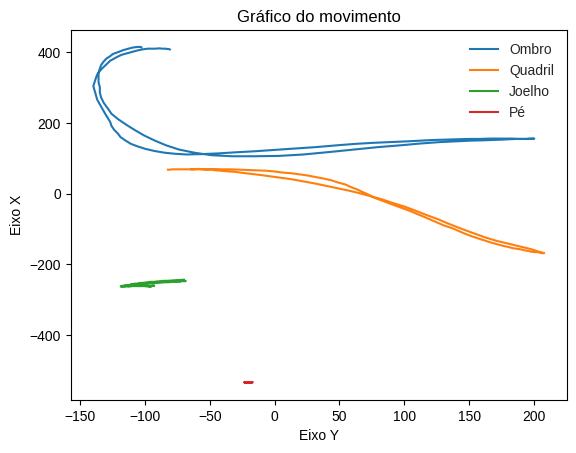

In [ ]:
for i, df in enumerate(dataframes):
    # Plotar coluna 1 em relação à coluna 2 para cada DataFrame
    texto = ''
    if i == 0:
      texto = 'Ombro'
    if i == 1:
      texto = 'Quadril'
    if i == 2:
      texto = 'Joelho'
    if i == 3:
      texto = 'Pé'
    plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=f'{texto}')

# titulos do gráfico
plt.style.use('seaborn')
plt.xlabel('Eixo Y')
plt.ylabel('Eixo X')
plt.title('Gráfico do movimento')
plt.legend()


# Exibir o gráfico
plt.show()

In [ ]:
coluna1 = df['x']
print(coluna1)

0     -17.29
1     -17.29
2     -17.29
3     -17.30
4     -17.31
       ...  
128   -18.22
129   -17.24
130   -17.25
131   -17.25
132   -17.26
Name: x, Length: 133, dtype: float64


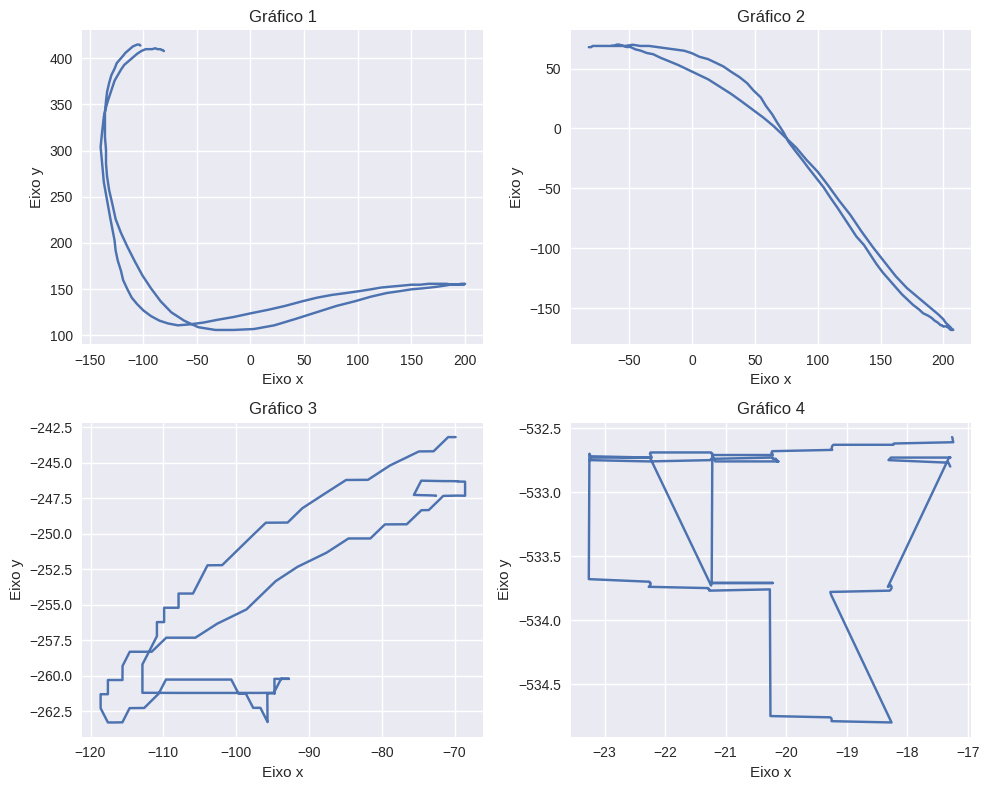

In [ ]:

fig, axs = plt.subplots(2, 2, figsize=(10, 8))


for i, df in enumerate(dataframes):
    linha = i // 2
    coluna = i % 2
    axs[linha, coluna].plot(df.iloc[:, 0], df.iloc[:, 1])
    axs[linha, coluna].set_title('Gráfico {}'.format(i + 1))
    axs[linha, coluna].set_xlabel('Eixo x')
    axs[linha, coluna].set_ylabel('Eixo y')

plt.tight_layout()
plt.show()

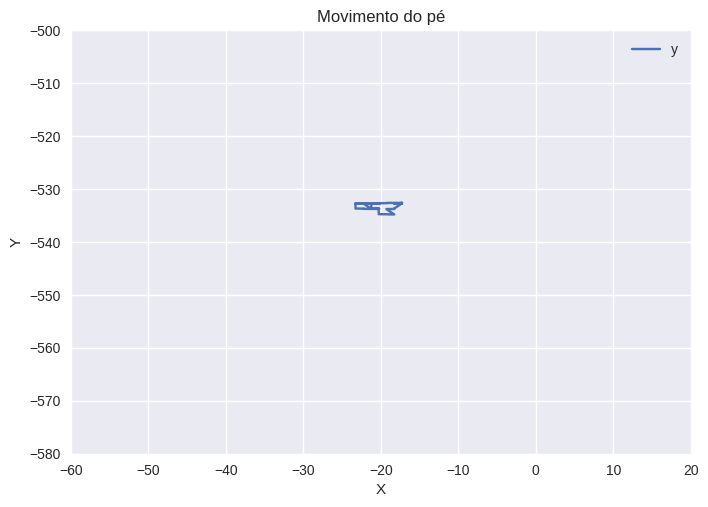

In [ ]:

df = dataframes[3]
ax = df.plot(x='x', y='y', kind='line')


ax.set_xlim(-60, 20)
ax.set_ylim(-580, -500)


plt.xlabel('X')
plt.ylabel('Y')
plt.title('Movimento do pé')


plt.show()

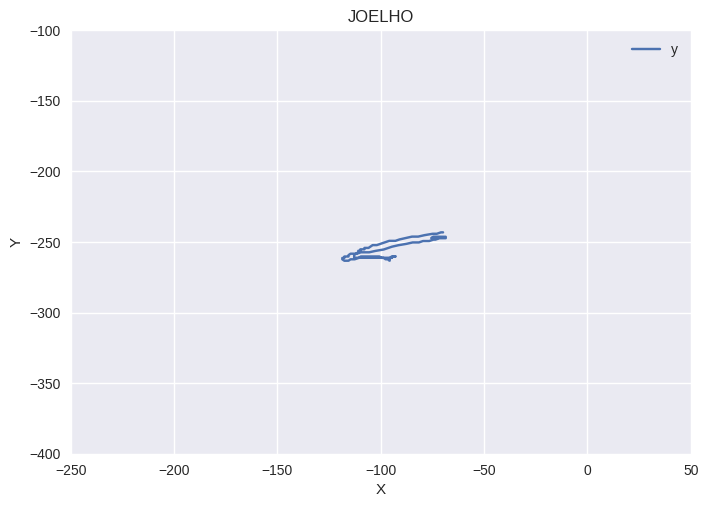

In [ ]:

df = dataframes[2]
ax = df.plot(x='x', y='y', kind='line')


ax.set_xlim(-250, 50)
ax.set_ylim(-400, -100)


plt.xlabel('X')
plt.ylabel('Y')
plt.title('JOELHO')

# Exibir o gráfico
plt.show()

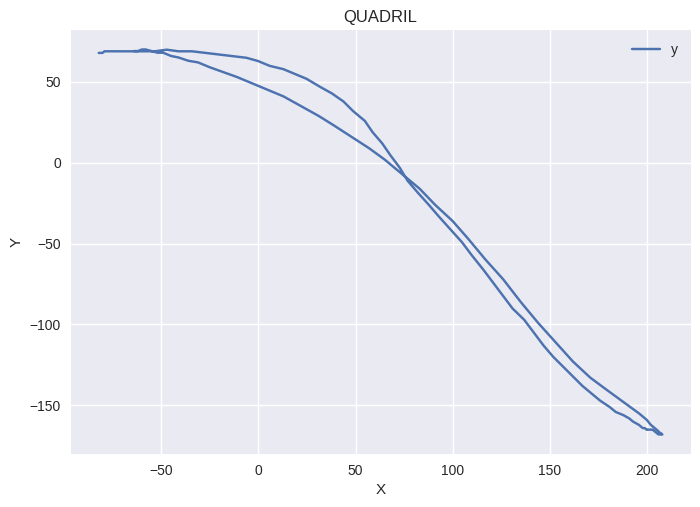

In [ ]:

df = dataframes[1]
ax = df.plot(x='x', y='y', kind='line')  # ou 'line', 'bar', 'hist', etc., dependendo do tipo de gráfico que deseja


plt.xlabel('X')
plt.ylabel('Y')
plt.title('QUADRIL')


plt.show()

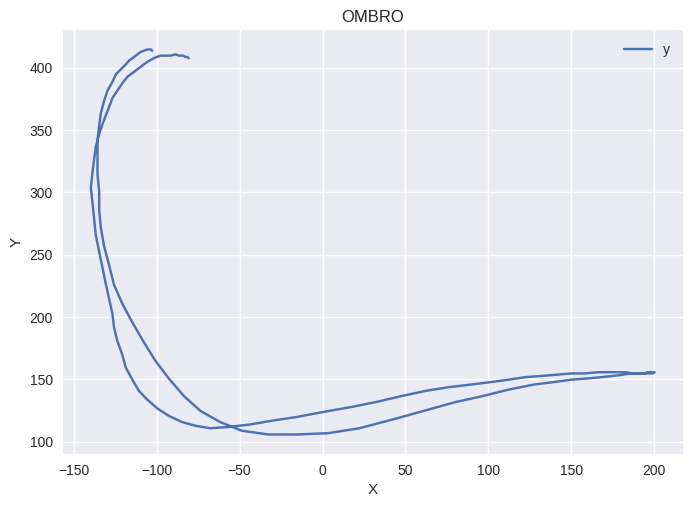

In [ ]:
# Plotar uma coluna em relação à outra
df = dataframes[0]
ax = df.plot(x='x', y='y', kind='line')  # ou 'line', 'bar', 'hist', etc., dependendo do tipo de gráfico que deseja

# Adicionar rótulos e título ao gráfico
plt.xlabel('X')
plt.ylabel('Y')
plt.title('OMBRO')

# Exibir o gráfico
plt.show()

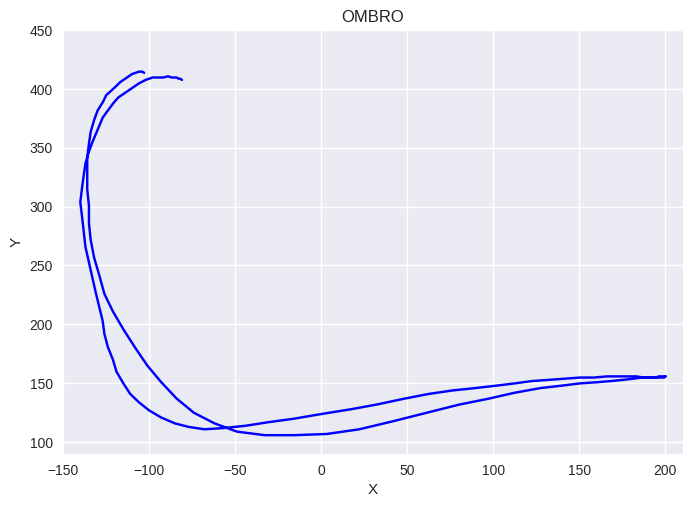

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df = dataframes[0]


# Função para inicializar o gráfico
def init():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('OMBRO')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('OMBRO')
    ax.plot(df['x'][:i], df['y'][:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(-150,210)  # Define os limites do eixo x
    ax.set_ylim(90,450)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df)+1, fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationOmbro.mp4', writer=writer)

plt.show()



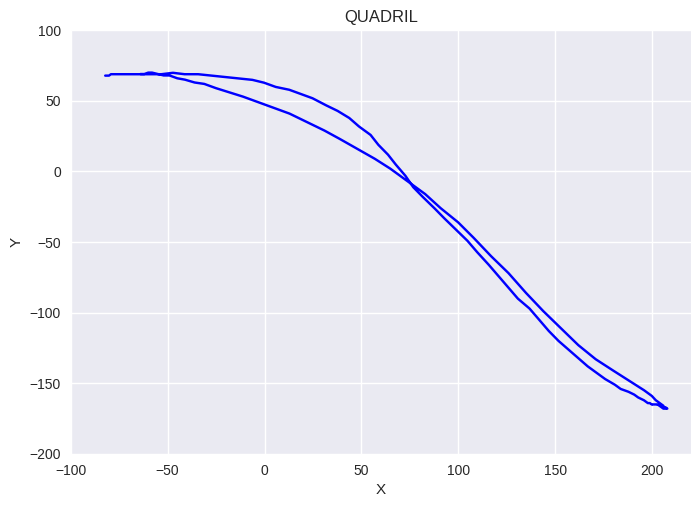

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df = dataframes[1]


# Função para inicializar o gráfico
def init():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('QUADRIL')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('QUADRIL')
    ax.plot(df['x'][:i], df['y'][:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(-100, 220)  # Define os limites do eixo x
    ax.set_ylim(-200, 100)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df)+1, fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationQuadril.mp4', writer=writer)

plt.show()

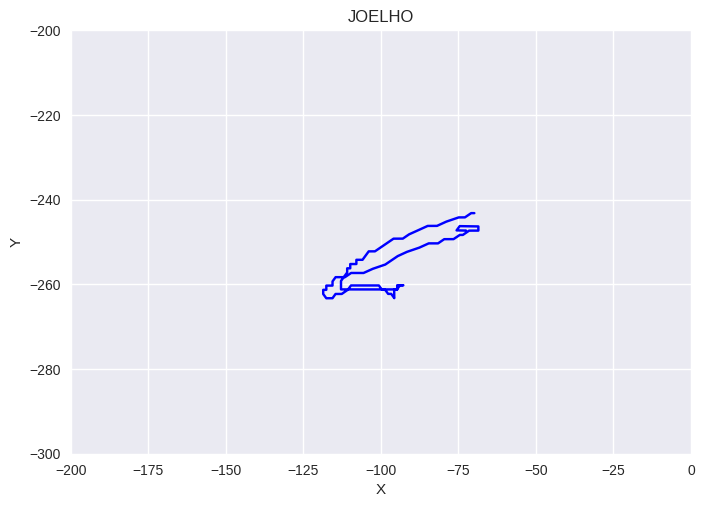

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df = dataframes[2]


# Função para inicializar o gráfico
def init():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('JOELHO')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('JOELHO')
    ax.plot(df['x'][:i], df['y'][:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(-200, 0)  # Define os limites do eixo x
    ax.set_ylim(-300, -200)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df)+1, fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationJoelho.mp4', writer=writer)

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

df = dataframes[3]


# Função para inicializar o gráfico
def init():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('PÉ')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('PÉ')
    ax.plot(df['x'][:i], df['y'][:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(-30, -10)  # Define os limites do eixo x
    ax.set_ylim(-540, -527.5)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df)+1, fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationPe.mp4', writer=writer)

plt.show()

IndexError: list index out of range

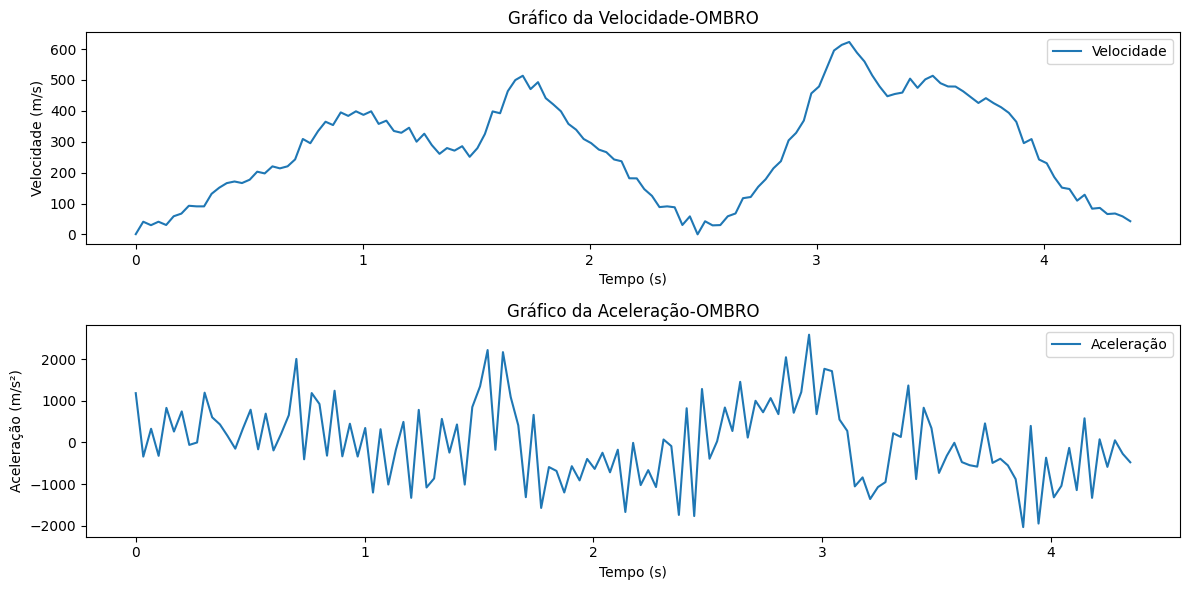

In [ ]:
# Calcular a velocidade
df = dataframes[0]
# Primeiro, calculamos as diferenças entre as posições e o tempo
delta_posicao_x = np.diff(df['x'])
delta_posicao_y = np.diff(df['y'])
delta_tempo = np.diff(df['t'])

# Em seguida, calculamos as velocidades em x e y dividindo as diferenças de posição pelo intervalo de tempo
velocidade_x = delta_posicao_x
velocidade_y = delta_posicao_y

# Calculamos a velocidade resultante utilizando o teorema de Pitágoras
velocidade = np.sqrt(velocidade_x**2 + velocidade_y**2)/delta_tempo

# Calcular a aceleração
# Primeiro, calculamos as diferenças entre as velocidades e o tempo
delta_velocidade = np.diff(velocidade)
delta_tempo_velocidade = delta_tempo[1:]

# Em seguida, calculamos a aceleração dividindo as diferenças de velocidade pelo intervalo de tempo
aceleracao = delta_velocidade / delta_tempo_velocidade

inclinacao_ombro = np.arctan2(velocidade_y, velocidade_x)


plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)
plt.plot(df['t'][:-1], velocidade, label='Velocidade')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Gráfico da Velocidade-OMBRO')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(df['t'][:-2], aceleracao, label='Aceleração')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Gráfico da Aceleração-OMBRO')
plt.legend()

plt.tight_layout()
plt.show()

# Salvar os valores de velocidade e aceleração em vetores numpy
vetor_vel_ombro = velocidade
vetor_acel_ombro = aceleracao

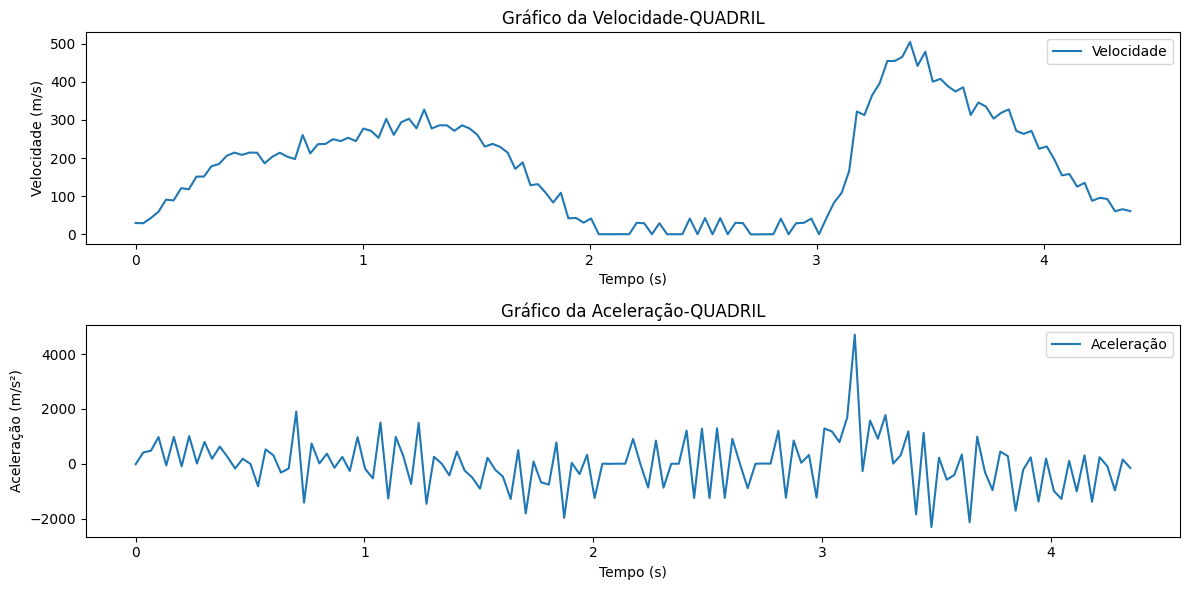

In [ ]:

df = dataframes[1]
# Primeiro, calculamos as diferenças entre as posições e o tempo
delta_posicao_x = np.diff(df['x'])
delta_posicao_y = np.diff(df['y'])
delta_tempo = np.diff(df['t'])

# Em seguida, calculamos as velocidades em x e y dividindo as diferenças de posição pelo intervalo de tempo
velocidade_x = delta_posicao_x / delta_tempo
velocidade_y = delta_posicao_y / delta_tempo

# Calculamos a velocidade resultante utilizando o teorema de Pitágoras
velocidade = np.sqrt(velocidade_x**2 + velocidade_y**2)

# Calcular a aceleração
# Primeiro, calculamos as diferenças entre as velocidades e o tempo
delta_velocidade = np.diff(velocidade)
delta_tempo_velocidade = delta_tempo[1:]  # Usamos o delta_tempo excluindo o primeiro elemento

# Em seguida, calculamos a aceleração dividindo as diferenças de velocidade pelo intervalo de tempo
aceleracao = delta_velocidade / delta_tempo_velocidade

#Inclinação
inclinacao_quadril = np.arctan2(velocidade_y, velocidade_x)

# Plotar os gráficos de velocidade e aceleração
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # Primeiro subplot para velocidade
plt.plot(df['t'][:-1], velocidade, label='Velocidade')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Gráfico da Velocidade-QUADRIL')
plt.legend()

plt.subplot(2, 1, 2)  # Segundo subplot para aceleração
plt.plot(df['t'][:-2], aceleracao, label='Aceleração')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Gráfico da Aceleração-QUADRIL')
plt.legend()

plt.tight_layout()
plt.show()

# Salvar os valores de velocidade e aceleração em vetores numpy
vetor_vel_quadril = velocidade
vetor_acel_quadril = aceleracao


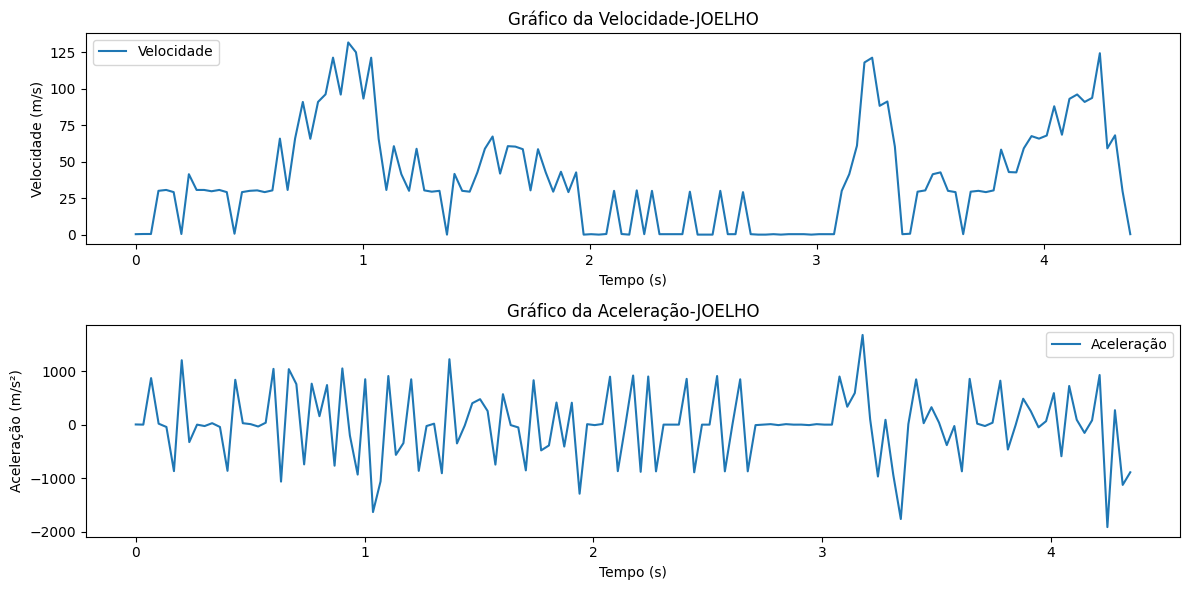

In [ ]:

df = dataframes[2]
# Primeiro, calculamos as diferenças entre as posições e o tempo
delta_posicao_x = np.diff(df['x'])
delta_posicao_y = np.diff(df['y'])
delta_tempo = np.diff(df['t'])

# Em seguida, calculamos as velocidades em x e y dividindo as diferenças de posição pelo intervalo de tempo
velocidade_x = delta_posicao_x / delta_tempo
velocidade_y = delta_posicao_y / delta_tempo

# Calculamos a velocidade resultante utilizando o teorema de Pitágoras
velocidade = np.sqrt(velocidade_x**2 + velocidade_y**2)

# Calcular a aceleração
# Primeiro, calculamos as diferenças entre as velocidades e o tempo
delta_velocidade = np.diff(velocidade)
delta_tempo_velocidade = delta_tempo[1:]  # Usamos o delta_tempo excluindo o primeiro elemento

# Em seguida, calculamos a aceleração dividindo as diferenças de velocidade pelo intervalo de tempo
aceleracao = delta_velocidade / delta_tempo_velocidade

#Inclinação
inclinacao_joelho = np.arctan2(velocidade_y, velocidade_x)

# Plotar os gráficos de velocidade e aceleração
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # Primeiro subplot para velocidade
plt.plot(df['t'][:-1], velocidade, label='Velocidade')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Gráfico da Velocidade-JOELHO')
plt.legend()

plt.subplot(2, 1, 2)  # Segundo subplot para aceleração
plt.plot(df['t'][:-2], aceleracao, label='Aceleração')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Gráfico da Aceleração-JOELHO')
plt.legend()

plt.tight_layout()
plt.show()

# Salvar os valores de velocidade e aceleração em vetores numpy
vetor_vel_joelho = velocidade
vetor_acel_joelho = aceleracao

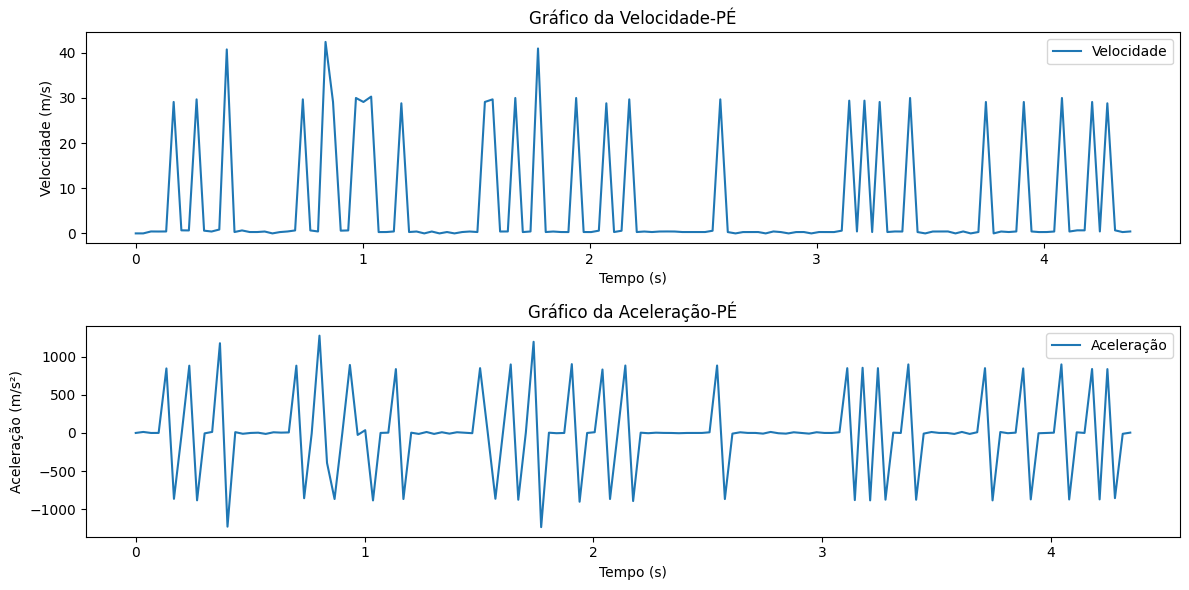

In [ ]:


df = dataframes[3]
# Primeiro, calculamos as diferenças entre as posições e o tempo
delta_posicao_x = np.diff(df['x'])
delta_posicao_y = np.diff(df['y'])
delta_tempo = np.diff(df['t'])

# Em seguida, calculamos as velocidades em x e y dividindo as diferenças de posição pelo intervalo de tempo
velocidade_x = delta_posicao_x / delta_tempo
velocidade_y = delta_posicao_y / delta_tempo

# Calculamos a velocidade resultante utilizando o teorema de Pitágoras
velocidade = np.sqrt(velocidade_x**2 + velocidade_y**2)

# Calcular a aceleração
# Primeiro, calculamos as diferenças entre as velocidades e o tempo
delta_velocidade = np.diff(velocidade)
delta_tempo_velocidade = delta_tempo[1:]  # Usamos o delta_tempo excluindo o primeiro elemento

# Em seguida, calculamos a aceleração dividindo as diferenças de velocidade pelo intervalo de tempo
aceleracao = delta_velocidade / delta_tempo_velocidade

#Inclinação
inclinacao_pe = np.arctan2(velocidade_y, velocidade_x)

# Plotar os gráficos de velocidade e aceleração
plt.figure(figsize=(12, 6))

plt.subplot(2, 1, 1)  # Primeiro subplot para velocidade
plt.plot(df['t'][:-1], velocidade, label='Velocidade')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.title('Gráfico da Velocidade-PÉ')
plt.legend()

plt.subplot(2, 1, 2)  # Segundo subplot para aceleração
plt.plot(df['t'][:-2], aceleracao, label='Aceleração')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Gráfico da Aceleração-PÉ')
plt.legend()

plt.tight_layout()
plt.show()


# Salvar os valores de velocidade e aceleração em vetores numpy

vetor_vel_pe = velocidade
vetor_acel_pe = aceleracao

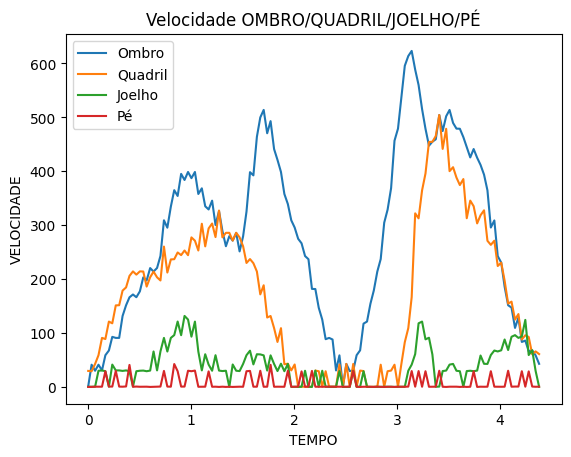

In [ ]:
for i, df in enumerate(dataframes):

    texto = ''
    if i == 0:
      texto = 'Ombro'
      plt.plot(df['t'][:-1], vetor_vel_ombro, label='Ombro')
    if i == 1:
      texto = 'Quadril'
      plt.plot(df['t'][:-1], vetor_vel_quadril, label='Quadril')
    if i == 2:
      texto = 'Joelho'
      plt.plot(df['t'][:-1], vetor_vel_joelho, label='Joelho')
    if i == 3:
      texto = 'Pé'
      plt.plot(df['t'][:-1], vetor_vel_pe, label='Pé')
    #plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=f'{texto}')

# Adicionar rótulos e título ao gráfico
plt.xlabel('TEMPO')
plt.ylabel('VELOCIDADE')
plt.title('Velocidade OMBRO/QUADRIL/JOELHO/PÉ')
plt.legend()  # Adiciona legenda com base nos rótulos especificados no loop

# Exibir o gráfico
plt.show()

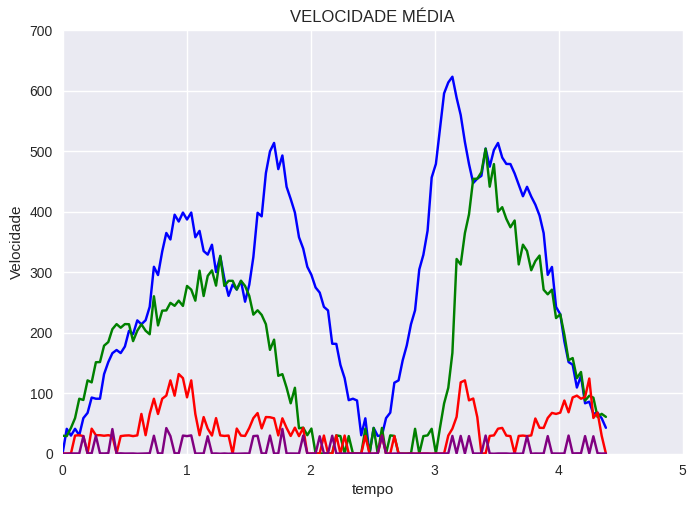

In [ ]:
# Supondo que você tenha definido dataframes[3] corretamente
df = dataframes[3]

VelO = np.array(vetor_vel_ombro)
VelQ = np.array(vetor_vel_quadril)
VelJ = np.array(vetor_vel_joelho)
VelP = np.array(vetor_vel_pe)

# Função para inicializar o gráfico
def init():
    ax.set_xlabel('tempo')
    ax.set_ylabel('Velocidade')
    ax.set_title('VELOCIDADE MÉDIA')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('tempo')
    ax.set_ylabel('Velocidade')
    ax.set_title('VELOCIDADE MÉDIA')
    ax.plot(df['t'][:i], VelO[:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.plot(df['t'][:i], VelQ[:i], color='green')  # Plota os dados até o i-ésimo ponto
    ax.plot(df['t'][:i], VelJ[:i], color='red',)  # Plota os dados até o i-ésimo ponto
    ax.plot(df['t'][:i], VelP[:i], color='purple')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(0, 5)  # Define os limites do eixo x
    ax.set_ylim(0, 700)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df), fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationVelTodos.mp4', writer=writer)

plt.show()

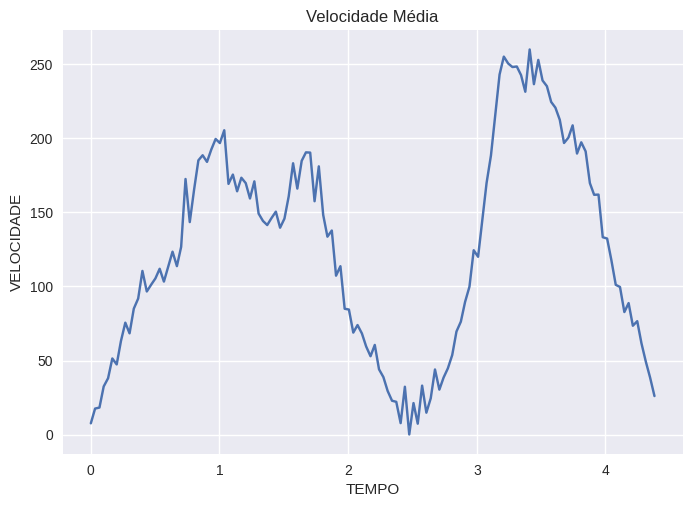

In [ ]:
Velocidade_media = []

# Calcule a média de cada elemento dos vetores
for i in range(len(vetor_vel_ombro)):
    soma_elementos = vetor_vel_ombro[i] + vetor_vel_quadril[i] + vetor_vel_joelho[i] + vetor_vel_pe[i]
    media_elemento = soma_elementos / 4
    Velocidade_media.append(media_elemento)

plt.plot(df['t'][:-1], Velocidade_media)


plt.xlabel('TEMPO')
plt.ylabel('VELOCIDADE')
plt.title('Velocidade Média')
plt.legend()


plt.show()



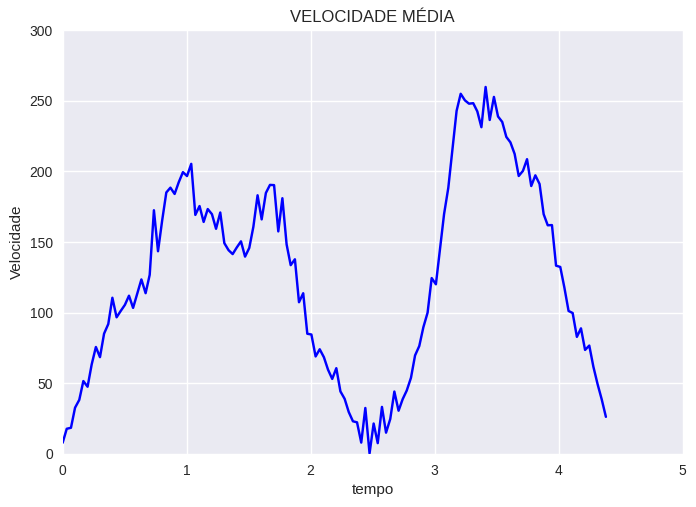

In [ ]:
# Supondo que você tenha definido dataframes[3] corretamente
df = dataframes[3]

Vel = np.array(Velocidade_media)

# Função para inicializar o gráfico
def init():
    ax.set_xlabel('tempo')
    ax.set_ylabel('VELOCIDADE')
    ax.set_title('VELOCIDADE MÉDIA')
    return ax,

# Função para atualizar o gráfico a cada quadro da animação
def animate(i, df):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('tempo')
    ax.set_ylabel('Velocidade')
    ax.set_title('VELOCIDADE MÉDIA')
    ax.plot(df['t'][:i], Vel[:i], color='blue')  # Plota os dados até o i-ésimo ponto
    ax.set_xlim(0, 5)  # Define os limites do eixo x
    ax.set_ylim(0, 300)  # Define os limites do eixo y
    return ax,

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Criando a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df), fargs=(df,), init_func=init, interval=100, blit=False)

# Salvar a animação como um arquivo de vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationVel.mp4', writer=writer)

plt.show()


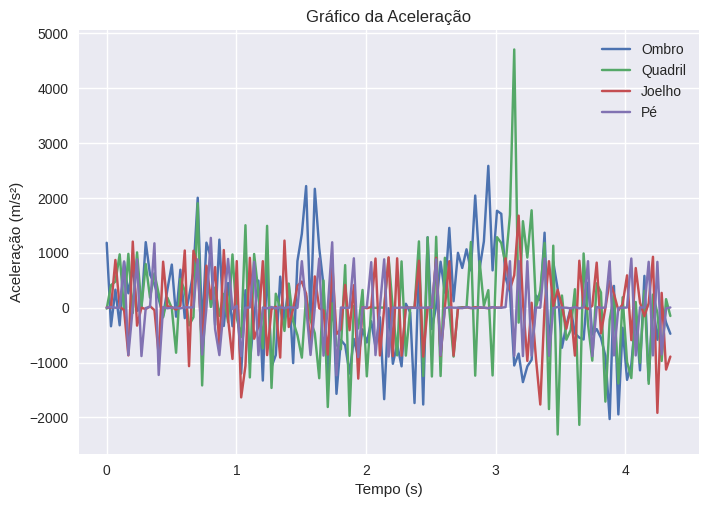

In [ ]:
for i, df in enumerate(dataframes):

    texto = ''
    if i == 0:
      texto = 'Ombro'
      plt.plot(df['t'][:-2], vetor_acel_ombro, label='Ombro')
    if i == 1:
      texto = 'Quadril'
      plt.plot(df['t'][:-2], vetor_acel_quadril, label='Quadril')
    if i == 2:
      texto = 'Joelho'
      plt.plot(df['t'][:-2], vetor_acel_joelho, label='Joelho')
    if i == 3:
      texto = 'Pé'
      plt.plot(df['t'][:-2], vetor_acel_pe, label='Pé')
    #plt.plot(df.iloc[:, 0], df.iloc[:, 1], label=f'{texto}')


plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.title('Gráfico da Aceleração')
plt.legend()

# Exibir o gráfico
plt.show()

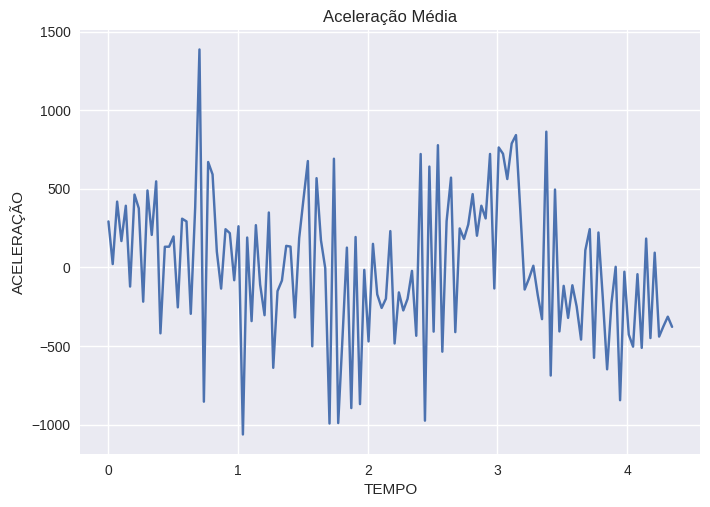

In [ ]:
Aceleracao_media = []

# Calcule a média de cada elemento dos vetores
for i in range(len(vetor_acel_ombro)):
    soma_elementos = vetor_acel_ombro[i] + vetor_acel_quadril[i] + vetor_acel_joelho[i] + vetor_acel_pe[i]
    media_elemento = soma_elementos / 4
    Aceleracao_media.append(media_elemento)

plt.plot(df['t'][:-2], Aceleracao_media)


plt.xlabel('TEMPO')
plt.ylabel('ACELERAÇÃO')
plt.title('Aceleração Média')
plt.legend()


plt.show()

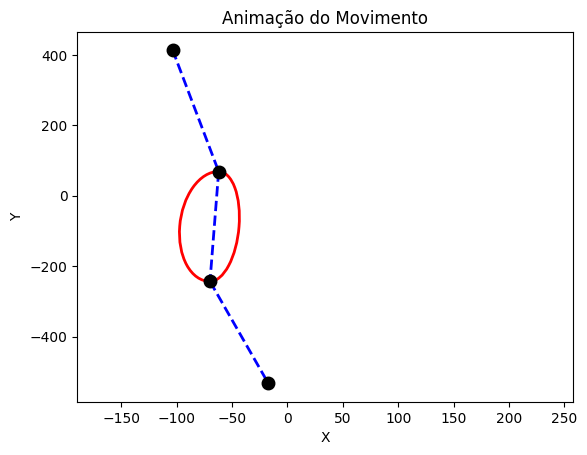

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib.patches import Arc

# Dataframes com os dados utilizados no trabalho
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Ordenar os dataframes pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Função para criar o arco do músculo
def add_muscle_arc(ax, P1, P2, color, inward=False):
    mid_x = (P1[0] + P2[0]) / 2
    mid_y = (P1[1] + P2[1]) / 2
    dx = P2[0] - P1[0]
    dy = P2[1] - P1[1]
    angle = np.degrees(np.arctan2(dy, dx))
    length = np.sqrt(dx**2 + dy**2)
    width = length  # Largura do arco
    height = length / 5 if not inward else length / 7 # Altura do arco

    # Ângulos para o arco
    theta1 = 0 if inward else 180
    theta2 = 180 if inward else 360

    arc = Arc((mid_x, mid_y), width, height, angle=angle, theta1=theta1, theta2=theta2, color=color, linewidth=2)
    ax.add_patch(arc)

# Configuração do gráfico inicial
fig, ax = plt.subplots()

# Função para inicializar o gráfico
def init():
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Animação do Movimento')
    return ax,

# Função para animar o gráfico
def animate(i):
    ax.clear()  # Limpa o eixo para atualização
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title('Animação do Movimento')

    if i > 0:
        # Plotar os pontos atuais em preto
        ax.plot(df1['x'].iloc[i-1], df1['y'].iloc[i-1], 'ko', markersize=8, markerfacecolor='black', markeredgewidth=2, markeredgecolor='black', zorder=3, label='Ponto 1')
        ax.plot(df2['x'].iloc[i-1], df2['y'].iloc[i-1], 'ko', markersize=8, markerfacecolor='black', markeredgewidth=2, markeredgecolor='black', zorder=3, label='Ponto 2')
        ax.plot(df3['x'].iloc[i-1], df3['y'].iloc[i-1], 'ko', markersize=8, markerfacecolor='black', markeredgewidth=2, markeredgecolor='black', zorder=3, label='Ponto 3')
        ax.plot(df4['x'].iloc[i-1], df4['y'].iloc[i-1], 'ko', markersize=8, markerfacecolor='black', markeredgewidth=2, markeredgecolor='black', zorder=3, label='Ponto 4')

        # Linhas conectando os pontos atuais em azul
        ax.plot([df1['x'].iloc[i-1], df2['x'].iloc[i-1]], [df1['y'].iloc[i-1], df2['y'].iloc[i-1]], 'b--', linewidth=2, zorder=2, label='Linha 1-2')
        ax.plot([df2['x'].iloc[i-1], df3['x'].iloc[i-1]], [df2['y'].iloc[i-1], df3['y'].iloc[i-1]], 'b--', linewidth=2, zorder=2, label='Linha 2-3')
        ax.plot([df3['x'].iloc[i-1], df4['x'].iloc[i-1]], [df3['y'].iloc[i-1], df4['y'].iloc[i-1]], 'b--', linewidth=2, zorder=2, label='Linha 3-4')

        # Adicionar arcos representando os músculos
        add_muscle_arc(ax, (df2['x'].iloc[i-1], df2['y'].iloc[i-1]), (df3['x'].iloc[i-1], df3['y'].iloc[i-1]), 'red', inward=False)  # Agonista
        add_muscle_arc(ax, (df2['x'].iloc[i-1], df2['y'].iloc[i-1]), (df3['x'].iloc[i-1], df3['y'].iloc[i-1]), 'red', inward=True)   # Antagonista

    # Ajustar a escala dos eixos x e y
    ax.set_xlim(min(df1['x'].min(), df2['x'].min(), df3['x'].min(), df4['x'].min()) - 50, max(df1['x'].max(), df2['x'].max(), df3['x'].max(), df4['x'].max()) + 50)
    ax.set_ylim(min(df1['y'].min(), df2['y'].min(), df3['y'].min(), df4['y'].min()) - 50, max(df1['y'].max(), df2['y'].max(), df3['y'].max(), df4['y'].max()) + 50)

    return ax,

# Criar a animação
ani = animation.FuncAnimation(fig, animate, frames=len(df1), init_func=init, interval=100, blit=False)

# Salvar em vídeo
Writer = animation.writers['ffmpeg']
writer = Writer(fps=15, metadata=dict(artist='Me'), bitrate=1800)
ani.save('animationMusculoexoerimental.mp4', writer=writer)



























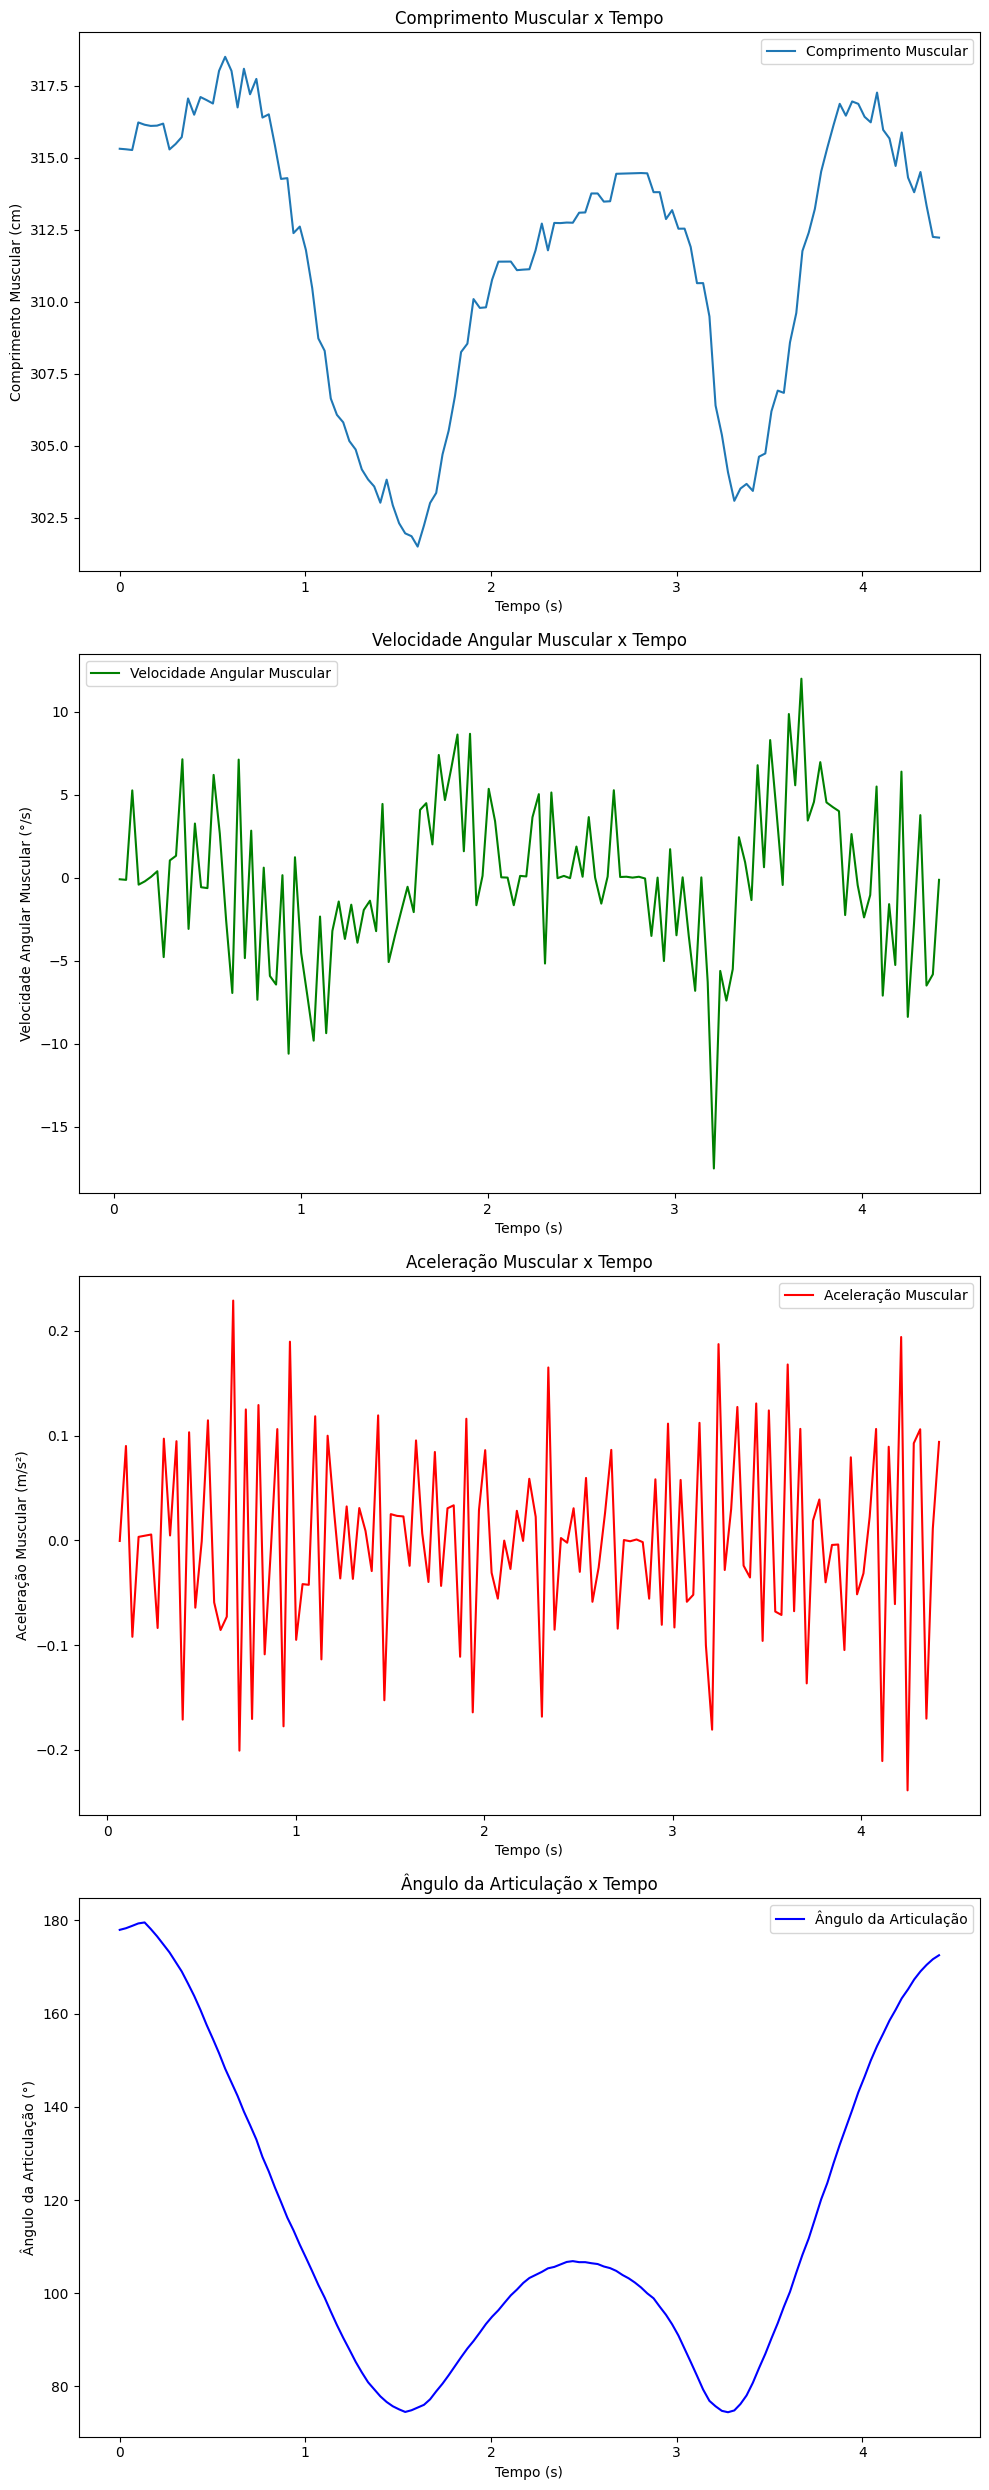

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes dataframes[0] a dataframes[3] já estejam definidos e ordenados
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Verifique se os dataframes estão ordenados pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos (se necessário)
df1['t'] = df1['t']   # Ajuste esta linha conforme a unidade atual do tempo
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular
df2['length'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2)

# Converter comprimento muscular para metros
df2['length'] = df2['length'] / 100

# Calcular a velocidade e aceleração muscular
df2['velocity'] = df2['length'].diff() / df2['t'].diff()
df2['acceleration'] = df2['velocity'].diff() / df2['t'].diff()

# Converter a velocidade para graus por segundo
df2['velocity_degrees_per_second'] = df2['velocity'] / df2['length'] * (180 / np.pi)

# Converter a aceleração para metros por segundo ao quadrado
df2['acceleration'] = df2['acceleration'] / 100

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        unit_vec1 = vec1 / np.linalg.norm(vec1)
        unit_vec2 = vec2 / np.linalg.norm(vec2)
        dot_product = np.dot(unit_vec1, unit_vec2)
        angle = np.arccos(dot_product)
        angles.append(np.degrees(angle))
    return angles

df2['angle'] = calculate_angles(df1, df2, df3)

# Plotar os gráficos
fig, axs = plt.subplots(4, 1, figsize=(10, 25))

# Comprimento muscular x Tempo
axs[0].plot(df2['t'], df2['length'] * 100, label='Comprimento Muscular')  # Convertendo de metros para cm para o gráfico
axs[0].set_xlabel('Tempo (s)')
axs[0].set_ylabel('Comprimento Muscular (cm)')
axs[0].set_title('Comprimento Muscular x Tempo')
axs[0].legend()

# Velocidade muscular x Tempo
axs[1].plot(df2['t'], df2['velocity_degrees_per_second'], label='Velocidade Angular Muscular', color='green')
axs[1].set_xlabel('Tempo (s)')
axs[1].set_ylabel('Velocidade Angular Muscular (°/s)')
axs[1].set_title('Velocidade Angular Muscular x Tempo')
axs[1].legend()

# Aceleração muscular x Tempo
axs[2].plot(df2['t'], df2['acceleration'], label='Aceleração Muscular', color='red')
axs[2].set_xlabel('Tempo (s)')
axs[2].set_ylabel('Aceleração Muscular (m/s²)')
axs[2].set_title('Aceleração Muscular x Tempo')
axs[2].legend()

# Ângulo da articulação x Tempo
axs[3].plot(df2['t'], df2['angle'], label='Ângulo da Articulação', color='blue')
axs[3].set_xlabel('Tempo (s)')
axs[3].set_ylabel('Ângulo da Articulação (°)')
axs[3].set_title('Ângulo da Articulação x Tempo')
axs[3].legend()

plt.tight_layout()
plt.show()





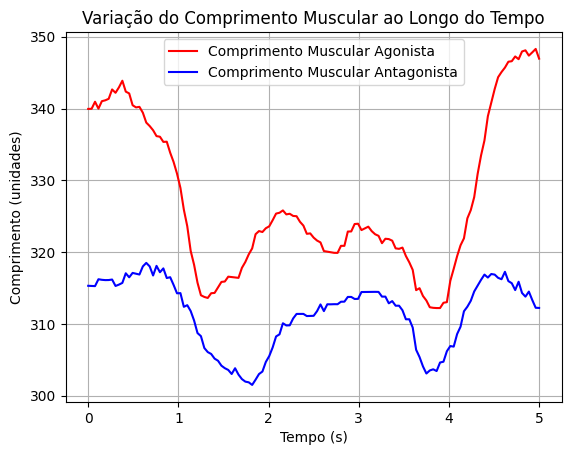

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Supondo que os dataframes já estejam definidos e ordenados
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Função para calcular a distância entre dois pontos
def calculate_distance(P1, P2):
    return np.sqrt((P2[0] - P1[0])**2 + (P2[1] - P1[1])**2)

# Função para calcular a variação do comprimento muscular
def calculate_length_variation(df1, df2, df3, df4):
    lengths = {'muscle1': [], 'muscle2': []}

    for i in range(len(df1)):
        # Pontos atuais
        P1_1 = (df1['x'].iloc[i], df1['y'].iloc[i])
        P2_1 = (df2['x'].iloc[i], df2['y'].iloc[i])
        P1_2 = (df2['x'].iloc[i], df2['y'].iloc[i])
        P2_2 = (df3['x'].iloc[i], df3['y'].iloc[i])

        # Calcular comprimento para os músculos
        length1 = calculate_distance(P1_1, P2_1)
        length2 = calculate_distance(P1_2, P2_2)

        # Adicionar comprimentos às listas
        lengths['muscle1'].append(length1)
        lengths['muscle2'].append(length2)

    return lengths

# Calcular a variação do comprimento muscular
lengths = calculate_length_variation(df1, df2, df3, df4)

# Definir a duração da animação e calcular o tempo em segundos
duration_seconds = 5
num_frames = len(lengths['muscle1'])
time_seconds = np.linspace(0, duration_seconds, num_frames)

# Criar o gráfico estático
fig, ax = plt.subplots()

# Plotar a variação do comprimento para cada músculo
ax.plot(time_seconds, lengths['muscle1'], label='Comprimento Muscular Agonista', color='red')
ax.plot(time_seconds, lengths['muscle2'], label='Comprimento Muscular Antagonista', color='blue')

# Configurar o gráfico
ax.set_xlabel('Tempo (s)')
ax.set_ylabel('Comprimento (unidades)')
ax.set_title('Variação do Comprimento Muscular ao Longo do Tempo')
ax.legend()
ax.grid(True)

# Salvar o gráfico como um arquivo de imagem
plt.savefig('muscle_length_variation_static.png')
plt.show()



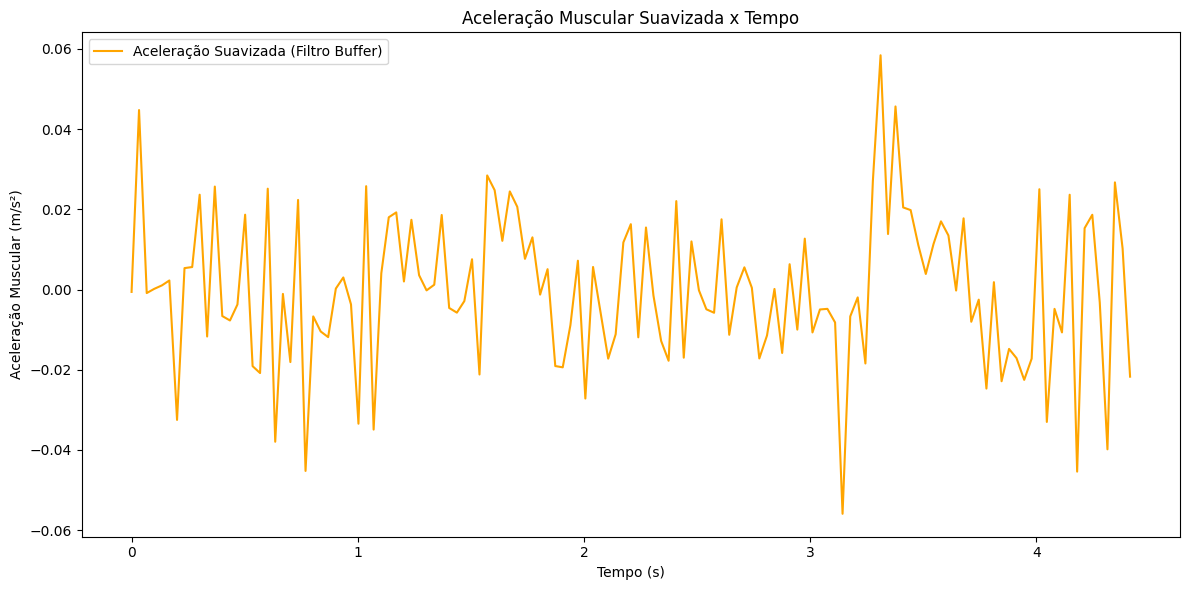

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes dataframes[0] a dataframes[3] já estejam definidos e ordenados
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Verifique se os dataframes estão ordenados pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos (se necessário)
df1['t'] = df1['t']   # Ajuste esta linha conforme a unidade atual do tempo
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular
df2['length'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2)

# Converter comprimento muscular para metros
df2['length'] = df2['length'] / 100

# Calcular a velocidade e aceleração muscular
df2['velocity'] = df2['length'].diff() / df2['t'].diff()
df2['acceleration'] = df2['velocity'].diff() / df2['t'].diff()

# Converter a velocidade para graus por segundo
df2['velocity_degrees_per_second'] = df2['velocity'] / df2['length'] * (180 / np.pi)

# Converter a aceleração para metros por segundo ao quadrado
df2['acceleration'] = df2['acceleration'] / 100

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        unit_vec1 = vec1 / np.linalg.norm(vec1)
        unit_vec2 = vec2 / np.linalg.norm(vec2)
        dot_product = np.dot(unit_vec1, unit_vec2)
        angle = np.arccos(dot_product)
        angles.append(np.degrees(angle))
    return angles

df2['angle'] = calculate_angles(df1, df2, df3)

# Função para aplicar o filtro buffer (média móvel)
def buffer_filter(data, window_size):
    """Aplicar filtro buffer (média móvel) aos dados."""
    return data.rolling(window=window_size, min_periods=1, center=True).mean()

# Aplicar o filtro buffer
window_size = 5
df2['acceleration_buffer_filtered'] = buffer_filter(df2['acceleration'], window_size)

# Plotar o gráfico da aceleração suavizada
plt.figure(figsize=(12, 6))

# Aceleração suavizada x Tempo
plt.plot(df2['t'], df2['acceleration_buffer_filtered'], label='Aceleração Suavizada (Filtro Buffer)', color='orange')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração Muscular (m/s²)')
plt.title('Aceleração Muscular Suavizada x Tempo')
plt.legend()

plt.tight_layout()
plt.show()






In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes já estejam definidos e ordenados
df1 = dataframes[0]  # Ponto 1
df2 = dataframes[1]  # Ponto 2
df3 = dataframes[2]  # Ponto 3
df4 = dataframes[3]  # Ponto 4

# Ordenar os dataframes pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos
df1['t'] = df1['t']
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular para o Músculo 1 e Músculo 2
df2['length_muscle1'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2) / 10
df2['length_muscle2'] = np.sqrt((df1['x'] - df4['x'])**2 + (df1['y'] - df4['y'])**2) / 10

# Calcular a velocidade e aceleração muscular para o Músculo 1 e Músculo 2
df2['velocity_muscle1'] = df2['length_muscle1'].diff() / df2['t'].diff()
df2['velocity_muscle2'] = df2['length_muscle2'].diff() / df2['t'].diff()
df2['acceleration_muscle1'] = df2['velocity_muscle1'].diff() / df2['t'].diff()
df2['acceleration_muscle2'] = df2['velocity_muscle2'].diff() / df2['t'].diff()

# Converter a velocidade e aceleração para as unidades corretas
df2['velocity_muscle1'] = df2['velocity_muscle1'] / 100
df2['velocity_muscle2'] = df2['velocity_muscle2'] / 100
df2['acceleration_muscle1'] = df2['acceleration_muscle1'] / 100
df2['acceleration_muscle2'] = df2['acceleration_muscle2'] / 100

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        unit_vec1 = vec1 / np.linalg.norm(vec1)
        unit_vec2 = vec2 / np.linalg.norm(vec2)
        dot_product = np.dot(unit_vec1, unit_vec2)
        angle = np.arccos(dot_product)
        angles.append(np.degrees(angle))
    return angles

# Calcular os ângulos para Músculo 1 e Músculo 2
df2['angle_muscle1'] = calculate_angles(df1, df2, df3)
df2['angle_muscle2'] = calculate_angles(df1, df2, df4)

# Adicionar uma coluna de força variável para cada músculo
df2['force_muscle1'] = 10 * np.sin(2 * np.pi * df2['t'] / df2['t'].max())
df2['force_muscle2'] = 10 * np.cos(2 * np.pi * df2['t'] / df2['t'].max())

# Calcular o torque para Músculo 1 e Músculo 2
def calculate_torque(length, angle, force):
    # Convert angle to radians for the sin function
    angle_rad = np.radians(angle)
    return force * length * np.sin(angle_rad)

df2['torque_muscle1'] = calculate_torque(df2['length_muscle1'], df2['angle_muscle1'], df2['force_muscle1'])
df2['torque_muscle2'] = calculate_torque(df2['length_muscle2'], df2['angle_muscle2'], df2['force_muscle2'])

# Preparar a tabela para exportação
output_df = pd.DataFrame({
    'Tempo (s)': df2['t'],
    'Comprimento Muscular Músculo 1 (cm)': df2['length_muscle1'],
    'Força Músculo 1 (N)': df2['force_muscle1'],
    'Ângulo Músculo 1 (graus)': df2['angle_muscle1'],
    'Torque Músculo 1 (Nm)': df2['torque_muscle1'],
    'Comprimento Muscular Músculo 2 (cm)': df2['length_muscle2'],
    'Força Músculo 2 (N)': df2['force_muscle2'],
    'Ângulo Músculo 2 (graus)': df2['angle_muscle2'],
    'Torque Músculo 2 (Nm)': df2['torque_muscle2'],
})

# Exportar para um arquivo Excel
output_df.to_excel('muscle_analysis.xlsx', index=False)

# Visualizar a tabela para confirmação
print(output_df.head())








   Tempo (s)  Comprimento Muscular Músculo 1 (cm)  Força Músculo 1 (N)  \
0      0.000                            31.530770             0.000000   
1      0.033                            31.528950             0.469572   
2      0.067                            31.526405             0.952278   
3      0.100                            31.622078             1.418665   
4      0.134                            31.614130             1.895901   

   Ângulo Músculo 1 (graus)  Torque Músculo 1 (Nm)  \
0                177.993369               0.000000   
1                178.336480               0.429789   
2                178.847506               0.603844   
3                179.370871               0.492582   
4                179.581401               0.437893   

   Comprimento Muscular Músculo 2 (cm)  Força Músculo 2 (N)  \
0                            94.270704            10.000000   
1                            94.273764             9.988969   
2                            94.379248   

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes já estejam definidos e ordenados
df1 = dataframes[0]  # Ponto 1
df2 = dataframes[1]  # Ponto 2
df3 = dataframes[2]  # Ponto 3
df4 = dataframes[3]  # Ponto 4

# Ordenar os dataframes pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos
df1['t'] = df1['t']
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular para o Músculo 1 e Músculo 2
df2['length_muscle1'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2) / 10
df2['length_muscle2'] = np.sqrt((df1['x'] - df4['x'])**2 + (df1['y'] - df4['y'])**2) / 10

# Ajustar o comprimento do Músculo 2 para ser mais realista
df2['length_muscle2'] = df2['length_muscle2'] / 2

# Calcular a velocidade e aceleração muscular para o Músculo 1 e Músculo 2
df2['velocity_muscle1'] = df2['length_muscle1'].diff() / df2['t'].diff()
df2['velocity_muscle2'] = df2['length_muscle2'].diff() / df2['t'].diff()
df2['acceleration_muscle1'] = df2['velocity_muscle1'].diff() / df2['t'].diff()
df2['acceleration_muscle2'] = df2['velocity_muscle2'].diff() / df2['t'].diff()

# Converter a velocidade e aceleração para as unidades corretas
df2['velocity_muscle1'] = df2['velocity_muscle1'] / 100
df2['velocity_muscle2'] = df2['velocity_muscle2'] / 100
df2['acceleration_muscle1'] = df2['acceleration_muscle1'] / 100
df2['acceleration_muscle2'] = df2['acceleration_muscle2'] / 100

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        norm_vec1 = np.linalg.norm(vec1)
        norm_vec2 = np.linalg.norm(vec2)
        # Verificar se os vetores não têm comprimento zero para evitar divisão por zero erro no algoritmo
        if norm_vec1 > 0 and norm_vec2 > 0:
            unit_vec1 = vec1 / norm_vec1
            unit_vec2 = vec2 / norm_vec2
            dot_product = np.dot(unit_vec1, unit_vec2)
            angle = np.arccos(np.clip(dot_product, -1.0, 1.0))
            angles.append(np.degrees(angle))
        else:
            angles.append(np.nan)
    return angles

# Calcular os ângulos para Músculo 1 e Músculo 2
df2['angle_muscle1'] = calculate_angles(df1, df2, df3)
df2['angle_muscle2'] = calculate_angles(df1, df2, df4)

# Adicionar uma coluna de força variável para cada músculo
df2['force_muscle1'] = 10 * np.sin(2 * np.pi * df2['t'] / df2['t'].max())
df2['force_muscle2'] = 10 * np.cos(2 * np.pi * df2['t'] / df2['t'].max())

# Calcula o torque para Músculo 1 e Músculo 2
def calculate_torque(length, angle, force):

    angle_rad = np.radians(angle)
    return force * length * np.sin(angle_rad)

df2['torque_muscle1'] = calculate_torque(df2['length_muscle1'], df2['angle_muscle1'], df2['force_muscle1'])
df2['torque_muscle2'] = calculate_torque(df2['length_muscle2'], df2['angle_muscle2'], df2['force_muscle2'])

# Preparar a tabela para exportação
output_df = pd.DataFrame({
    'Tempo (s)': df2['t'],
    'Comprimento Muscular Músculo 1 (cm)': df2['length_muscle1'],
    'Força Músculo 1 (N)': df2['force_muscle1'],
    'Ângulo Músculo 1 (graus)': df2['angle_muscle1'],
    'Torque Músculo 1 (Nm)': df2['torque_muscle1'],
    'Comprimento Muscular Músculo 2 (cm)': df2['length_muscle2'],
    'Força Músculo 2 (N)': df2['force_muscle2'],
    'Ângulo Músculo 2 (graus)': df2['angle_muscle2'],
    'Torque Músculo 2 (Nm)': df2['torque_muscle2'],
})

# Exportar para um arquivo Excel
output_df.to_excel('muscle_analysis_updated.xlsx', index=False)

# Visualizar a tabela para confirmação
print(output_df.head())


   Tempo (s)  Comprimento Muscular Músculo 1 (cm)  Força Músculo 1 (N)  \
0      0.000                            31.530770             0.000000   
1      0.033                            31.528950             0.469572   
2      0.067                            31.526405             0.952278   
3      0.100                            31.622078             1.418665   
4      0.134                            31.614130             1.895901   

   Ângulo Músculo 1 (graus)  Torque Músculo 1 (Nm)  \
0                177.993369               0.000000   
1                178.336480               0.429789   
2                178.847506               0.603844   
3                179.370871               0.492582   
4                179.581401               0.437893   

   Comprimento Muscular Músculo 2 (cm)  Força Músculo 2 (N)  \
0                            47.135352            10.000000   
1                            47.136882             9.988969   
2                            47.189624   

In [ ]:
import numpy as np
import pandas as pd

# Supondo que os dataframes já estejam definidos e ordenados
df1 = dataframes[0]  # Ponto 1
df2 = dataframes[1]  # Ponto 2
df3 = dataframes[2]  # Ponto 3
df4 = dataframes[3]  # Ponto 4

# Ordenar os dataframes pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Calcular o comprimento muscular para o Músculo 1 (quadril) e Músculo 2 (joelho)
df2['length_muscle1'] = np.sqrt((df3['x'].values - df2['x'].values)**2 + (df3['y'].values - df2['y'].values)**2) / 10
df2['length_muscle2'] = np.sqrt((df1['x'].values - df4['x'].values)**2 + (df1['y'].values - df4['y'].values)**2) / 10

# Ajustar o comprimento do Músculo 2 para ser mais realista
df2['length_muscle2'] = df2['length_muscle2'] / 2

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        norm_vec1 = np.linalg.norm(vec1)
        norm_vec2 = np.linalg.norm(vec2)
        if norm_vec1 > 0 and norm_vec2 > 0:
            unit_vec1 = vec1 / norm_vec1
            unit_vec2 = vec2 / norm_vec2
            dot_product = np.dot(unit_vec1, unit_vec2)
            angle = np.arccos(np.clip(dot_product, -1.0, 1.0))
            angles.append(np.degrees(angle))
        else:
            angles.append(np.nan)  # Se um dos vetores tem comprimento zero, retorna NaN
    return angles

# Calcular os ângulos para o quadril e joelho
df2['angle_quadril'] = calculate_angles(df1, df2, df3)
df2['angle_joelho'] = calculate_angles(df1, df2, df4)

# Adicionar uma coluna de força variável para cada músculo
df2['force_quadril'] = 10 * np.sin(2 * np.pi * df2['t'] / df2['t'].max())
df2['force_joelho'] = 10 * np.cos(2 * np.pi * df2['t'] / df2['t'].max())

# Calcular o torque para o quadril e joelho
def calculate_torque(length, angle, force):
    angle_rad = np.radians(angle)  # Convert angle to radians
    return force * length * np.sin(angle_rad)

df2['torque_quadril'] = calculate_torque(df2['length_muscle1'], df2['angle_quadril'], df2['force_quadril'])
df2['torque_joelho'] = calculate_torque(df2['length_muscle2'], df2['angle_joelho'], df2['force_joelho'])

# Preparar a tabela para exportação
output_df = pd.DataFrame({
    'Tempo (s)': df2['t'],
    'Torque Quadril (Nm)': df2['torque_quadril'],
    'Torque Joelho (Nm)': df2['torque_joelho']
})

# Exportar para um arquivo Excel
output_df.to_excel('torque_results.xlsx', index=False)

# Visualizar a tabela para confirmação
print(output_df.head())






   Tempo (s)  Torque Quadril (Nm)  Torque Joelho (Nm)
0      0.000             0.000000           52.734667
1      0.033             0.429789           50.559458
2      0.067             0.603844           46.963889
3      0.100             0.492582           43.126106
4      0.134             0.437893           37.259114


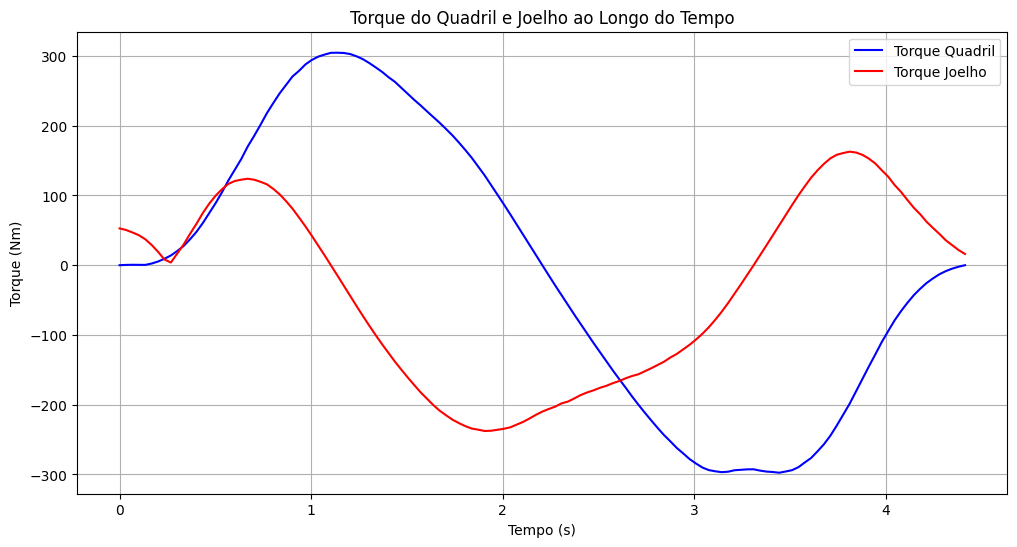

In [ ]:
import matplotlib.pyplot as plt

# Certifique-se de que o DataFrame 'output_df' está definido e contém os dados necessários

# Criar o gráfico
plt.figure(figsize=(12, 6))

# Plotar o torque do quadril
plt.plot(output_df['Tempo (s)'], output_df['Torque Quadril (Nm)'], label='Torque Quadril', color='blue')

# Plotar o torque do joelho
plt.plot(output_df['Tempo (s)'], output_df['Torque Joelho (Nm)'], label='Torque Joelho', color='red')

# Adicionar rótulos e título
plt.xlabel('Tempo (s)')
plt.ylabel('Torque (Nm)')
plt.title('Torque do Quadril e Joelho ao Longo do Tempo')
plt.legend()
plt.grid(True)

# Exibir o gráfico
plt.show()


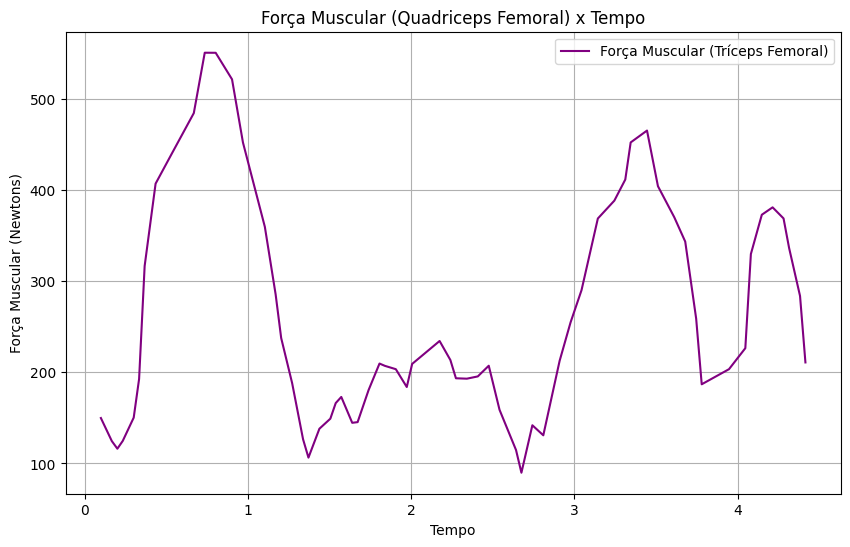

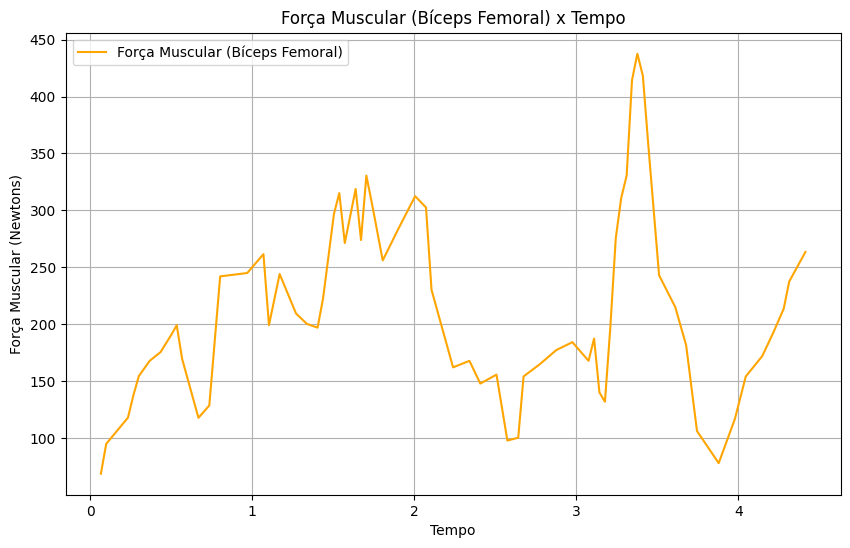

In [ ]:
from scipy.signal import savgol_filter

# Função para aplicar o filtro de Savitzky-Golay
def savgol_smooth(series, window_length, polyorder):
    return savgol_filter(series, window_length, polyorder)

# Parâmetros do filtro de Savitzky-Golay
window_length = 11  # Tamanho da janela (deve ser ímpar)
polyorder = 2       # Ordem do polinômio

# Aplicar o filtro de Savitzky-Golay
df2_positive_force_df2_df3['smoothed_force_df2_df3_sg'] = savgol_smooth(df2_positive_force_df2_df3['force_df2_df3'], window_length, polyorder)
df2_positive_force_df2_df4['smoothed_force_df2_df4_sg'] = savgol_smooth(df2_positive_force_df2_df4['force_df2_df4'], window_length, polyorder)

# Plotar o gráfico da força muscular suavizada para o arco df2-df3 (Tríceps Femoral) usando Savitzky-Golay
plt.figure(figsize=(10, 6))
plt.plot(df2_positive_force_df2_df3['t'], df2_positive_force_df2_df3['smoothed_force_df2_df3_sg'], label='Força Muscular (Tríceps Femoral)', color='purple')
plt.xlabel('Tempo')
plt.ylabel('Força Muscular (Newtons)')
plt.title('Força Muscular (Quadriceps Femoral) x Tempo')
plt.legend()
plt.grid(True)
plt.show()

# Plotar o gráfico da força muscular suavizada para o arco df2-df4 (Bíceps Femoral) usando Savitzky-Golay
plt.figure(figsize=(10, 6))
plt.plot(df2_positive_force_df2_df4['t'], df2_positive_force_df2_df4['smoothed_force_df2_df4_sg'], label='Força Muscular (Bíceps Femoral)', color='orange')
plt.xlabel('Tempo')
plt.ylabel('Força Muscular (Newtons)')
plt.title('Força Muscular (Bíceps Femoral) x Tempo')
plt.legend()
plt.grid(True)
plt.show()




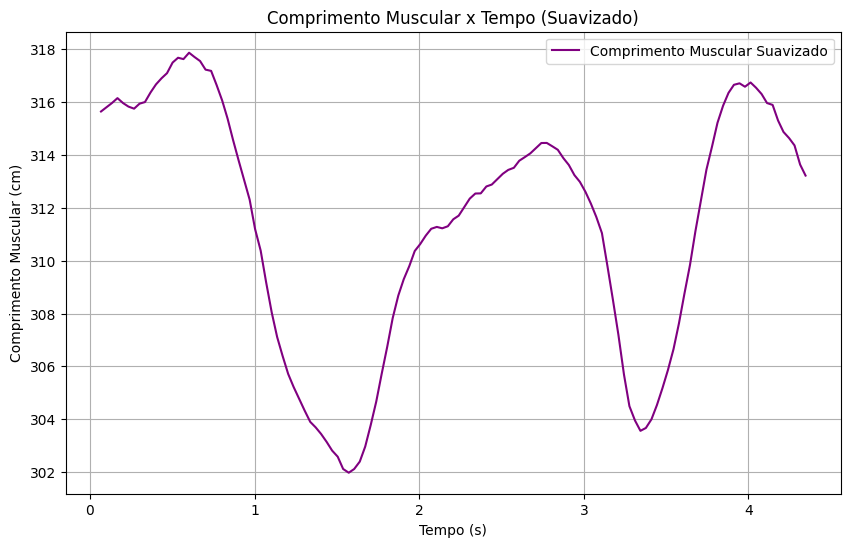

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes dataframes[0] a dataframes[3] já estejam definidos e ordenados
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Verifique se os dataframes estão ordenados pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos (se necessário)
df1['t'] = df1['t']   # Ajuste esta linha conforme a unidade atual do tempo
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular
df2['length'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2)

# Converter comprimento muscular para metros
df2['length'] = df2['length'] / 100

# Aplicar o filtro de média móvel para suavizar o comprimento muscular
window_size = 5  # Tamanho da janela do filtro de média móvel
df2['length_smoothed'] = df2['length'].rolling(window=window_size, center=True).mean()

# Plotar o gráfico do comprimento muscular suavizado
plt.figure(figsize=(10, 6))
plt.plot(df2['t'], df2['length_smoothed'] * 100, label='Comprimento Muscular Suavizado', color='purple')  # Convertendo de metros para cm para o gráfico
plt.xlabel('Tempo (s)')
plt.ylabel('Comprimento Muscular (cm)')
plt.title('Comprimento Muscular x Tempo (Suavizado)')
plt.legend()
plt.grid(True)
plt.show()




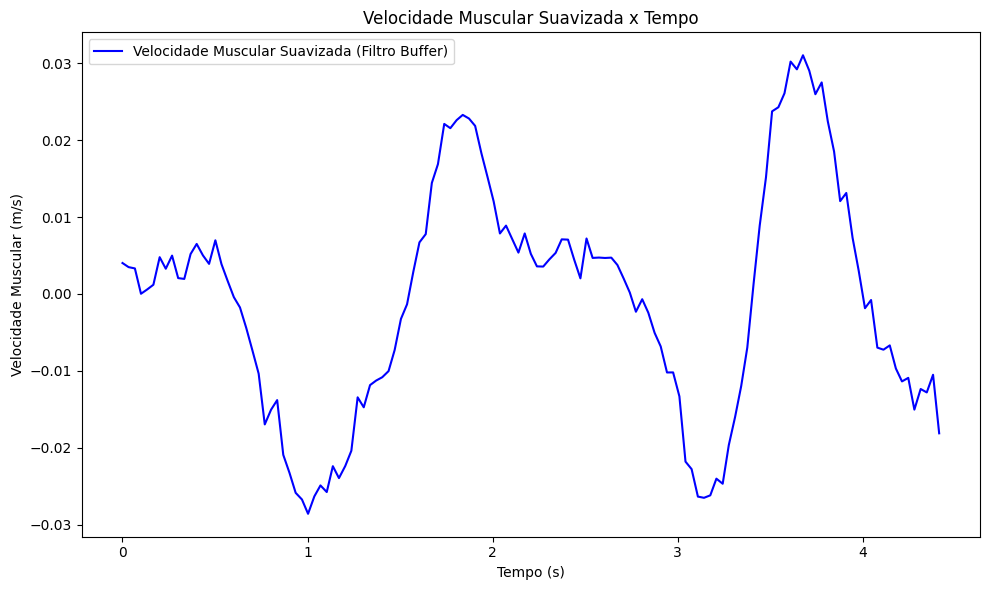

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Supondo que os dataframes dataframes[0] a dataframes[3] já estejam definidos e ordenados
df1 = dataframes[0]
df2 = dataframes[1]
df3 = dataframes[2]
df4 = dataframes[3]

# Ordenar os dataframes pelo tempo
df1 = df1.sort_values('t')
df2 = df2.sort_values('t')
df3 = df3.sort_values('t')
df4 = df4.sort_values('t')

# Converter o tempo para segundos (ajuste conforme necessário)
df1['t'] = df1['t']
df2['t'] = df2['t']
df3['t'] = df3['t']
df4['t'] = df4['t']

# Calcular o comprimento muscular
df2['length'] = np.sqrt((df3['x'] - df2['x'])**2 + (df3['y'] - df2['y'])**2)

# Converter comprimento muscular para centímetros
df2['length'] = df2['length'] / 10

# Calcular a velocidade e aceleração muscular
df2['velocity'] = df2['length'].diff() / df2['t'].diff()
df2['acceleration'] = df2['velocity'].diff() / df2['t'].diff()

# Converter a velocidade para metros por segundo
df2['velocity'] = df2['velocity'] / 100

# Converter a aceleração para metros por segundo ao quadrado
df2['acceleration'] = df2['acceleration'] / 100

# Função para calcular o ângulo da articulação
def calculate_angles(df1, df2, df3):
    angles = []
    for i in range(len(df1)):
        vec1 = np.array([df1['x'].iloc[i] - df2['x'].iloc[i], df1['y'].iloc[i] - df2['y'].iloc[i]])
        vec2 = np.array([df3['x'].iloc[i] - df2['x'].iloc[i], df3['y'].iloc[i] - df2['y'].iloc[i]])
        unit_vec1 = vec1 / np.linalg.norm(vec1)
        unit_vec2 = vec2 / np.linalg.norm(vec2)
        dot_product = np.dot(unit_vec1, unit_vec2)
        angle = np.arccos(dot_product)
        angles.append(np.degrees(angle))
    return angles

df2['angle'] = calculate_angles(df1, df2, df3)

# Função para aplicar o filtro buffer (média móvel)
def buffer_filter(data, window_size):
    """Aplicar filtro buffer (média móvel) aos dados."""
    return data.rolling(window=window_size, min_periods=1, center=True).mean()

# Parâmetro para a janela do filtro buffer
window_size = 11  # Tamanho da janela da média móvel (deve ser ímpar para manter o centro)

# Aplicar o filtro buffer à velocidade
df2['velocity_buffer_filtered'] = buffer_filter(df2['velocity'].fillna(0), window_size)

# Plotar o gráfico da velocidade suavizada
plt.figure(figsize=(10, 6))

plt.plot(df2['t'], df2['velocity_buffer_filtered'], label='Velocidade Muscular Suavizada (Filtro Buffer)', color='blue')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade Muscular (m/s)')
plt.title('Velocidade Muscular Suavizada x Tempo')
plt.legend()

plt.tight_layout()
plt.show()
